<a href="https://colab.research.google.com/github/alexuslivesey-ctrl/DSA_495-labs/blob/main/Lab_01_Livesey%2C_Alexus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1: Emotion Classification and Error Analysis
## Student starter notebook · DSA 495

**Value:** 20% of the final course grade  
**Work format:** Individual

This lab follows the same text from tokenization through two classification
workflows:

1. inspect what the DistilBERT and BART tokenizers receive;
2. evaluate a specialized DistilBERT emotion classifier; and
3. evaluate BART as a zero-shot classifier after selecting label wording on
   a separate development set.

Record your interpretations and answers in the supplied `README.md`.
Keep notebook outputs visible in the submitted copy. You are responsible
for understanding and checking every submitted result.

Use **Runtime → Change runtime type → T4 GPU**, then run cells from top to
bottom. BART evaluates six hypotheses for each message and may take several
minutes even with a GPU.

In [3]:
# Run once at the beginning of a fresh Colab session.
%pip install -q "transformers==4.57.6" "scikit-learn>=1.5,<2" "matplotlib>=3.8,<4" pandas

## Setup

In [4]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

SEED = 495
LABELS = ["sadness", "joy", "love", "anger", "fear", "surprise"]
N_DEV_PER_CLASS = 5
N_SOURCE_TEST = 2000
N_DEVELOPMENT = len(LABELS) * N_DEV_PER_CLASS
N_EVALUATION = N_SOURCE_TEST - N_DEVELOPMENT

COLAB_LAB_DIR = Path(
    "/content/drive/MyDrive/DSA-TextAnalysis/DSA495-2026/Labs/Lab 1"
)
LAB_DIR = COLAB_LAB_DIR if COLAB_LAB_DIR.exists() else Path.cwd()
TEST_PATH = LAB_DIR / "emotion.csv"

print("Data file:", TEST_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data file: /content/drive/MyDrive/DSA-TextAnalysis/DSA495-2026/Labs/Lab 1/emotion.csv


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Model and evaluation setup
import gc
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from transformers import AutoTokenizer, pipeline, set_seed

ENCODER_ID = "bhadresh-savani/distilbert-base-uncased-finetuned-emotion"
ENCODER_REVISION = "11350faca8e85c4861766cec4c30dec55fd06bb9"
BART_ID = "facebook/bart-large-mnli"
BART_REVISION = "d7645e127eaf1aefc7862fd59a17a5aa8558b8ce"

set_seed(SEED)
DEVICE = 0 if torch.cuda.is_available() else -1
BATCH_SIZE = 16 if DEVICE == 0 else 8
print("Device:", torch.cuda.get_device_name(0) if DEVICE == 0 else "CPU")

Device: Tesla T4


## 0. Create a clean development/evaluation split

The development set contains five randomly selected messages per emotion.
Use it only to choose between the two zero-shot label formulations. Both
classifiers are evaluated on the same remaining 1,970 messages.

In [7]:
full_test = pd.read_csv(TEST_PATH, dtype={"example_id": "string", "text": "string"})

required_columns = {
    "example_id", "source_split", "source_row", "text", "label_id", "label"
}
assert len(full_test) == N_SOURCE_TEST
assert required_columns.issubset(full_test.columns)
assert full_test["example_id"].is_unique
assert full_test["source_split"].eq("test").all()
assert set(full_test["label"]) == set(LABELS)

rng = random.Random(SEED)
development_indices = []
for label in LABELS:
    candidates = full_test.index[full_test["label"] == label].tolist()
    development_indices.extend(rng.sample(candidates, N_DEV_PER_CLASS))

development_indices = sorted(development_indices)
development = full_test.loc[development_indices].copy().reset_index(drop=True)
evaluation = full_test.drop(index=development_indices).copy().reset_index(drop=True)

assert len(development) == N_DEVELOPMENT
assert len(evaluation) == N_EVALUATION
assert not set(development["example_id"]) & set(evaluation["example_id"])

In [8]:
split_counts = pd.DataFrame({
    "full_test": full_test["label"].value_counts(),
    "development": development["label"].value_counts(),
    "evaluation": evaluation["label"].value_counts(),
}).reindex(LABELS).fillna(0).astype(int)
split_counts["evaluation_percent"] = (
    100 * split_counts["evaluation"] / len(evaluation)
)
display(split_counts)

,full_test,development,evaluation,evaluation_percent
label,,,,
sadness,581,5,576,29.238579
joy,695,5,690,35.025381
love,159,5,154,7.817259
anger,275,5,270,13.705584
fear,224,5,219,11.116751
surprise,66,5,61,3.096447


**Write in `README.md`:** Answer Q1 using the displayed counts. Do not call
this a training/test split; neither model is trained in this notebook.

## 1. Tokenization: What does the model actually receive?

In [9]:
# Load tokenizers only. Model weights are loaded in later sections.
encoder_tokenizer = AutoTokenizer.from_pretrained(
    ENCODER_ID, revision=ENCODER_REVISION
)
bart_tokenizer = AutoTokenizer.from_pretrained(
    BART_ID, revision=BART_REVISION
)
tokenizers = {"DistilBERT": encoder_tokenizer, "BART": bart_tokenizer}

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/333 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
# Replace S1 and S2 with your own diagnostic messages before continuing.
# Together, your examples should include at least two features such as
# capitalization, negation, an emoji, a contraction, or an unfamiliar word.
tokenization_examples = pd.DataFrame([
    ("I1", "instructor", "I can't believe you remembered my birthday!"),
    ("I2", "instructor", "I am not happy about this result."),
    ("I3", "instructor", "I am HAPPY about this result."),
    ("I4", "instructor", "I am happy about this result."),
    ("I5", "instructor", "That surprise made my day 😊!"),
    ("I6", "instructor", "The floccinaucinihilipilification of my work made me angry."),
    ("S1", "student", "Wow, that was an amazing goal that I will cherish!"),
    ("S2", "student", "I heard something, but I am unsure what is could have been."),
], columns=["example_id", "origin", "text"])

display(tokenization_examples)

,example_id,origin,text
0,I1,instructor,I can't believe you remembered my birthday!
1,I2,instructor,I am not happy about this result.
2,I3,instructor,I am HAPPY about this result.
3,I4,instructor,I am happy about this result.
4,I5,instructor,That surprise made my day 😊!
5,I6,instructor,The floccinaucinihilipilification of my work m...
6,S1,student,"Wow, that was an amazing goal that I will cher..."
7,S2,student,"I heard something, but I am unsure what is cou..."


In [11]:
# STUDENT CODE BLOCK 1: build the token table (about 8–10 lines).
# The required output columns and validation checks are supplied.
token_rows = []
for example in tokenization_examples.itertuples():
    for tokenizer_name, tokenizer in tokenizers.items():
        # TODO: tokenize once without and once with special tokens.
        content_ids = tokenizer.encode(example.text, add_special_tokens=False)
        all_ids = tokenizer.encode(example.text, add_special_tokens=True)

        token_rows.append({
            "example_id": example.example_id,
            "tokenizer": tokenizer_name,
            # TODO: convert the content IDs to tokenizer vocabulary strings.
            "token_strings": tokenizer.convert_ids_to_tokens(content_ids),
            "token_ids": content_ids,
            # TODO: record both sequence lengths.
            "content_length": len(content_ids),
            "length_with_special_tokens": len(all_ids),
        })

# TODO: convert token_rows to a DataFrame.
token_table = pd.DataFrame(token_rows)

expected_token_columns = {
    "example_id", "tokenizer", "token_strings", "token_ids",
    "content_length", "length_with_special_tokens",
}
assert len(token_table) == len(tokenization_examples) * len(tokenizers)
assert set(token_table.columns) == expected_token_columns
with pd.option_context("display.max_colwidth", None):
    display(token_table)

,example_id,tokenizer,token_strings,token_ids,content_length,length_with_special_tokens
0,I1,DistilBERT,"[i, can, ', t, believe, you, remembered, my, birthday, !]","[1045, 2064, 1005, 1056, 2903, 2017, 4622, 2026, 5798, 999]",10,12
1,I1,BART,"[I, Ġcan, 't, Ġbelieve, Ġyou, Ġremembered, Ġmy, Ġbirthday, !]","[100, 64, 75, 679, 47, 8715, 127, 4115, 328]",9,11
2,I2,DistilBERT,"[i, am, not, happy, about, this, result, .]","[1045, 2572, 2025, 3407, 2055, 2023, 2765, 1012]",8,10
3,I2,BART,"[I, Ġam, Ġnot, Ġhappy, Ġabout, Ġthis, Ġresult, .]","[100, 524, 45, 1372, 59, 42, 898, 4]",8,10
4,I3,DistilBERT,"[i, am, happy, about, this, result, .]","[1045, 2572, 3407, 2055, 2023, 2765, 1012]",7,9
5,I3,BART,"[I, Ġam, ĠH, APP, Y, Ġabout, Ġthis, Ġresult, .]","[100, 524, 289, 17167, 975, 59, 42, 898, 4]",9,11
6,I4,DistilBERT,"[i, am, happy, about, this, result, .]","[1045, 2572, 3407, 2055, 2023, 2765, 1012]",7,9
7,I4,BART,"[I, Ġam, Ġhappy, Ġabout, Ġthis, Ġresult, .]","[100, 524, 1372, 59, 42, 898, 4]",7,9
8,I5,DistilBERT,"[that, surprise, made, my, day, [UNK], !]","[2008, 4474, 2081, 2026, 2154, 100, 999]",7,9
9,I5,BART,"[That, Ġsurprise, Ġmade, Ġmy, Ġday, ĠðŁĺ, Ĭ, !]","[1711, 2755, 156, 127, 183, 17841, 27969, 328]",8,10


In [12]:
# Use an artificially short limit to make omitted content visible.
long_text = (
    "I described the train ride, the weather, and every stop along the way. " * 4
    + "Despite the ordinary journey, I am terrified about what happens tomorrow."
)

truncation_rows = []
for tokenizer_name, tokenizer in tokenizers.items():
    full = tokenizer(long_text, add_special_tokens=True)
    shortened = tokenizer(
        long_text,
        add_special_tokens=True,
        truncation=True,
        max_length=32,
        return_offsets_mapping=True,
    )
    content_offsets = [
        (start, end)
        for start, end in shortened["offset_mapping"]
        if end > start
    ]
    last_character = max(end for start, end in content_offsets)
    truncation_rows.append({
        "tokenizer": tokenizer_name,
        "full_length": len(full["input_ids"]),
        "truncated_length": len(shortened["input_ids"]),
        "retained_text": tokenizer.decode(
            shortened["input_ids"], skip_special_tokens=True
        ),
        "omitted_suffix": long_text[last_character:],
    })

with pd.option_context("display.max_colwidth", None):
    display(pd.DataFrame(truncation_rows))

,tokenizer,full_length,truncated_length,retained_text,omitted_suffix
0,DistilBERT,79,32,"i described the train ride, the weather, and every stop along the way. i described the train ride, the weather, and every stop along the","way. I described the train ride, the weather, and every stop along the way. I described the train ride, the weather, and every stop along the way. Despite the ordinary journey, I am terrified about what happens tomorrow."
1,BART,79,32,"I described the train ride, the weather, and every stop along the way. I described the train ride, the weather, and every stop along the","way. I described the train ride, the weather, and every stop along the way. I described the train ride, the weather, and every stop along the way. Despite the ordinary journey, I am terrified about what happens tomorrow."


**Write in `README.md`:** Answer Q2 and Q3. Token IDs are vocabulary
indices, so their numerical size has no semantic meaning and IDs from the
two tokenizers are not directly comparable.

## 2. Specialized encoder classification

In [13]:
# A constant reference baseline chosen before evaluation.
baseline_label = "joy"
y_true = evaluation["label"].to_numpy()
baseline_predictions = np.repeat(baseline_label, len(evaluation))

def metric_row(method, truth, predictions, seconds=None):
    return {
        "method": method,
        "accuracy": accuracy_score(truth, predictions),
        "macro_f1": f1_score(
            truth,
            predictions,
            labels=LABELS,
            average="macro",
            zero_division=0,
        ),
        "inference_seconds": seconds,
    }

display(pd.DataFrame([
    metric_row("Always predict joy", y_true, baseline_predictions)
]))

,method,accuracy,macro_f1,inference_seconds
0,Always predict joy,0.350254,0.086466,None


In [14]:
encoder = pipeline(
    "text-classification",
    model=ENCODER_ID,
    revision=ENCODER_REVISION,
    tokenizer=encoder_tokenizer,
    device=DEVICE,
)

encoder_label_mapping = {
    int(key): value.lower()
    for key, value in encoder.model.config.id2label.items()
}
print("Checkpoint label mapping:", encoder_label_mapping)
assert set(encoder_label_mapping.values()) == set(LABELS)

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Device set to use cuda:0


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Checkpoint label mapping: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [15]:
# PROVIDED: run the expensive model inference. Model loading is excluded
# from the timer. Complete the processing block below after this finishes.
start = time.perf_counter()
raw_encoder_predictions = encoder(
    evaluation["text"].tolist(),
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=encoder_tokenizer.model_max_length,
    top_k=None,
)
encoder_seconds = time.perf_counter() - start

# STUDENT CODE BLOCK 2: process and evaluate predictions
# (about 13–15 lines). Keep the canonical LABELS column order.
# TODO: turn each list of label/score dictionaries into one DataFrame row.
encoder_scores = pd.DataFrame(
  [{d["label"]: d["score"] for d in row}
for row in raw_encoder_predictions
]).reindex(columns=LABELS)
assert encoder_scores.shape == (len(evaluation), len(LABELS))
assert list(encoder_scores.columns) == LABELS

results = evaluation.copy()
# TODO: store the highest-scoring label and its score for every message.
results["encoder_prediction"] = encoder_scores.idxmax(axis=1)
results["encoder_score"] = encoder_scores.max(axis=1)
encoder_predictions = results["encoder_prediction"].to_numpy()

# TODO: calculate accuracy and macro-F1 directly.
encoder_accuracy = accuracy_score(y_true, encoder_predictions)
encoder_macro_f1 = f1_score(
    y_true,
    encoder_predictions,
    labels=LABELS,
    average="macro",
    zero_division=0,
)

# TODO: retain errors and sort them from highest to lowest model score.
encoder_errors = (
results[results["label"] != results["encoder_prediction"]]
    .sort_values("encoder_score", ascending=False)
)

encoder_comparison = pd.DataFrame([
    metric_row("Always predict joy", y_true, baseline_predictions),
    {
        "method": "DistilBERT",
        "accuracy": encoder_accuracy,
        "macro_f1": encoder_macro_f1,
        "inference_seconds": encoder_seconds,
    },
])
display(encoder_comparison)

,method,accuracy,macro_f1,inference_seconds
0,Always predict joy,0.350254,0.086466,NaN
1,DistilBERT,0.924365,0.880256,6.182604


,precision,recall,f1-score,support
sadness,0.973451,0.954861,0.964067,576.000000
joy,0.972393,0.918841,0.944858,690.000000
love,0.769231,0.909091,0.833333,154.000000
anger,0.901060,0.944444,0.922242,270.000000
fear,0.878924,0.894977,0.886878,219.000000
surprise,0.707692,0.754098,0.730159,61.000000
accuracy,0.924365,0.924365,0.924365,0.924365
macro avg,0.867125,0.896052,0.880256,1970.000000
weighted avg,0.928457,0.924365,0.925563,1970.000000


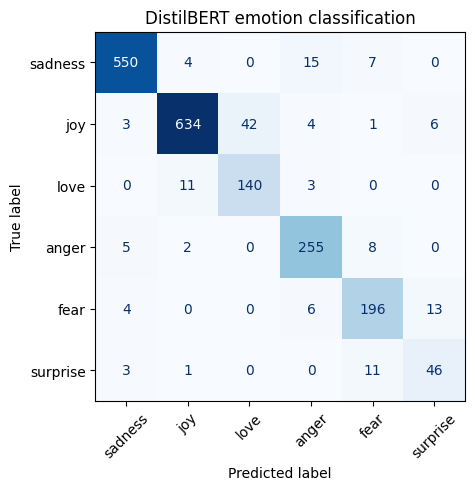

In [16]:
encoder_report = pd.DataFrame(
    classification_report(
        y_true,
        encoder_predictions,
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
).T
display(encoder_report)

ConfusionMatrixDisplay.from_predictions(
    y_true,
    encoder_predictions,
    labels=LABELS,
    display_labels=LABELS,
    cmap="Blues",
    colorbar=False,
    xticks_rotation=45,
)
plt.title("DistilBERT emotion classification")
plt.grid(False)
plt.show()

In [17]:
# PROVIDED: inspect the error table created in Student Code Block 2.
display(
    encoder_errors[
        ["example_id", "text", "label", "encoder_prediction", "encoder_score"]
    ].head(12)
)

,example_id,text,label,encoder_prediction,encoder_score
1295,emotion_test_01314,ive blogged and i feel strange about it,surprise,fear,0.998750
1358,emotion_test_01377,i walked to school he felt the bounce in his s...,love,joy,0.998552
802,emotion_test_00816,whenever i put myself in others shoes and try ...,anger,joy,0.998424
1010,emotion_test_01026,i have not conducted a survey but it is quite ...,sadness,fear,0.998219
1898,emotion_test_01928,i feel inside cause life is like a game someti...,fear,sadness,0.997864
1252,emotion_test_01270,i feel very saddened that the king whom i once...,joy,sadness,0.997822
1188,emotion_test_01206,ive come to feel about a supporting character ...,joy,love,0.997463
1363,emotion_test_01382,i cannot even begin to express in words the de...,surprise,sadness,0.997266
410,emotion_test_00415,i loved the feeling i got during an amazing sl...,joy,surprise,0.996692
189,emotion_test_00193,i really dont like quinn because i feel like s...,anger,sadness,0.996099


**Write in `README.md`:** Complete Q4 and Q5. Examine the message text;
do not infer an error pattern only from the labels or scores.

## 3. Zero-shot classification and label wording

In [18]:
# Release encoder weights before loading the larger BART model.
del encoder, raw_encoder_predictions
gc.collect()
if DEVICE == 0:
    torch.cuda.empty_cache()

zero_shot = pipeline(
    "zero-shot-classification",
    model=BART_ID,
    revision=BART_REVISION,
    tokenizer=bart_tokenizer,
    device=DEVICE,
)

print("BART classification head:", zero_shot.model.config.id2label)

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Device set to use cuda:0


BART classification head: {0: 'contradiction', 1: 'neutral', 2: 'entailment'}


In [19]:
HYPOTHESIS_TEMPLATE = "This text expresses {}."
FORMULATIONS = {
    "A: emotion names": dict(zip(LABELS, LABELS)),
    "B: expanded descriptions": {
        "sadness": "sadness or unhappiness",
        "joy": "happiness or joy",
        "love": "love or affection",
        "anger": "anger or frustration",
        "fear": "fear or anxiety",
        "surprise": "surprise or astonishment",
    },
}

def run_zero_shot(texts, label_mapping):
    description_to_label = {
        description: label
        for label, description in label_mapping.items()
    }
    start = time.perf_counter()
    outputs = zero_shot(
        list(texts),
        candidate_labels=list(label_mapping.values()),
        hypothesis_template=HYPOTHESIS_TEMPLATE,
        multi_label=False,
        batch_size=BATCH_SIZE,
    )
    seconds = time.perf_counter() - start
    scores = pd.DataFrame([
        {
            description_to_label[description]: score
            for description, score in zip(row["labels"], row["scores"])
        }
        for row in outputs
    ]).reindex(columns=LABELS)
    return scores, seconds

In [20]:
development_rows = []
development_predictions = development.copy()

for formulation_name, label_mapping in FORMULATIONS.items():
    scores, seconds = run_zero_shot(development["text"], label_mapping)
    predictions = scores.idxmax(axis=1)
    development_predictions[formulation_name] = predictions
    development_rows.append(
        metric_row(
            formulation_name,
            development["label"],
            predictions,
            seconds,
        )
    )

development_comparison = pd.DataFrame(development_rows).set_index("method")
display(development_comparison)

# STUDENT DECISION LINE: select the formulation with the highest
# development macro-F1. Pandas chooses A if the values tie exactly.
selected_formulation = "B: expanded descriptions"
selected_labels = FORMULATIONS[selected_formulation]
print("Selected before evaluation:", selected_formulation)

changed = development_predictions.loc[
    development_predictions["A: emotion names"]
    != development_predictions["B: expanded descriptions"]
]
display(
    changed[
        [
            "example_id", "text", "label",
            "A: emotion names", "B: expanded descriptions",
        ]
    ].head(8)
)


,accuracy,macro_f1,inference_seconds
method,,,
A: emotion names,0.500000,0.464388,1.631332
B: expanded descriptions,0.566667,0.552279,1.500962


Selected before evaluation: B: expanded descriptions


,example_id,text,label,A: emotion names,B: expanded descriptions
4,emotion_test_00332,i have better things to do than to feel humili...,sadness,surprise,sadness
6,emotion_test_00518,i watched the news at the tv,anger,sadness,surprise
7,emotion_test_00582,im happy but i feel all this pressure to do on...,sadness,sadness,anger
11,emotion_test_00679,i feel like an emotional cutter,sadness,sadness,anger
12,emotion_test_00712,i stop feeling guilty,sadness,surprise,sadness
13,emotion_test_00767,i feel like most teams would have appeased jac...,anger,surprise,anger
17,emotion_test_01116,i fancied the terrains there and feel keen to ...,joy,joy,love
21,emotion_test_01509,i decide that picking the easy route would get...,fear,fear,sadness


In [21]:
# Final zero-shot evaluation. Do not revise labels after viewing these results.
zero_shot_scores, zero_shot_seconds = run_zero_shot(
    evaluation["text"], selected_labels
)
results["zero_shot_prediction"] = zero_shot_scores.idxmax(axis=1)
results["zero_shot_score"] = zero_shot_scores.max(axis=1)
zero_shot_predictions = results["zero_shot_prediction"].to_numpy()

final_comparison = pd.DataFrame([
    metric_row("Always predict joy", y_true, baseline_predictions),
    metric_row(
        "DistilBERT", y_true, encoder_predictions, encoder_seconds
    ),
    metric_row(
        f"BART zero-shot ({selected_formulation})",
        y_true,
        zero_shot_predictions,
        zero_shot_seconds,
    ),
])
display(final_comparison)

,method,accuracy,macro_f1,inference_seconds
0,Always predict joy,0.350254,0.086466,NaN
1,DistilBERT,0.924365,0.880256,6.182604
2,BART zero-shot (B: expanded descriptions),0.536548,0.479474,118.025805


,precision,recall,f1-score,support
sadness,0.655290,0.666667,0.660929,576.000000
joy,0.840909,0.428986,0.568138,690.000000
love,0.301887,0.415584,0.349727,154.000000
anger,0.536122,0.522222,0.529081,270.000000
fear,0.523077,0.621005,0.567850,219.000000
surprise,0.121212,0.590164,0.201117,61.000000
accuracy,0.536548,0.536548,0.536548,0.536548
macro avg,0.496416,0.540771,0.479474,1970.000000
weighted avg,0.645109,0.536548,0.561446,1970.000000


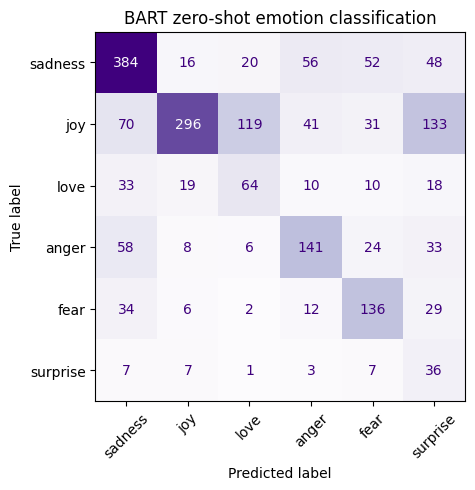

In [22]:
zero_shot_report = pd.DataFrame(
    classification_report(
        y_true,
        zero_shot_predictions,
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
).T
display(zero_shot_report)

ConfusionMatrixDisplay.from_predictions(
    y_true,
    zero_shot_predictions,
    labels=LABELS,
    display_labels=LABELS,
    cmap="Purples",
    colorbar=False,
    xticks_rotation=45,
)
plt.title("BART zero-shot emotion classification")
plt.grid(False)
plt.show()

In [23]:
disagreements = results.loc[
    results["encoder_prediction"] != results["zero_shot_prediction"]
].copy()
disagreements["encoder_correct"] = (
    disagreements["encoder_prediction"] == disagreements["label"]
)
disagreements["zero_shot_correct"] = (
    disagreements["zero_shot_prediction"] == disagreements["label"]
)
disagreements["outcome"] = np.select(
    [disagreements["encoder_correct"], disagreements["zero_shot_correct"]],
    ["encoder only correct", "zero-shot only correct"],
    default="both incorrect",
)

display(disagreements["outcome"].value_counts().rename("count").to_frame())

# Show at least one example from each available outcome, then fill to four.
selected_indices = disagreements.groupby("outcome", sort=True).head(1).index.tolist()
selected_indices += [
    index
    for index in disagreements.index
    if index not in selected_indices
][: max(0, 4 - len(selected_indices))]

four_disagreements = disagreements.loc[selected_indices[:4]]
with pd.option_context("display.max_colwidth", None):
    display(
        four_disagreements[
            [
                "example_id", "text", "label", "encoder_prediction",
                "zero_shot_prediction", "outcome",
            ]
        ]
    )

,count
outcome,
encoder only correct,812
zero-shot only correct,48
both incorrect,44


,example_id,text,label,encoder_prediction,zero_shot_prediction,outcome
2,emotion_test_00002,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,sadness,love,encoder only correct
70,emotion_test_00072,i am right handed however i play billiards left handed naturally so me trying to play right handed feels weird,surprise,fear,surprise,zero-shot only correct
96,emotion_test_00098,i feel my heart is tortured by what i have done,anger,fear,sadness,both incorrect
4,emotion_test_00004,i was feeling a little vain when i did this one,sadness,sadness,surprise,encoder only correct


**Write in `README.md`:** Complete Q6–Q9. Scores from DistilBERT and BART
come from different classification procedures and should not be treated as
directly comparable probabilities of correctness.

## Submission check

Before submitting one `.zip` file through Canvas:

- replace both student tokenization examples;
- run every cell and keep outputs visible;
- complete all nine questions and the AI-use statement in `README.md`;
- make sure `README.md` identifies every included file and explains how to
  rerun the analysis; and
- include the completed notebook and `README.md` in the archive.

Do not include restricted or sensitive data. The course dataset is already
available through the course Google Drive location.